# Portfolio problem

In [1]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.constants import IN_SAMPLE_TIME_WINDOW, OUT_OF_SAMPLE_TIME_WINDOW
from mis_dro.plot import *

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":12})
# rc('text', usetex=True)


In [2]:
# mmc2_dir = Path("/", "Users", "patrick", "Datasets", "misdro", "mmc2")
mmc2_dir = Path("/dcs/pg20/u1508153/datasets/misdro/mmc2")
assert mmc2_dir.exists()
dgp = "DowJones"
returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Assets_Returns", header=None)
index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Index_Returns", header=None)

returns_df

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0.007383,0.012783,0.005208,-0.038285,-0.012098,-0.056079,-0.041475,-0.032967,-0.023324,0.010955,...,0.024652,-0.027021,-0.015650,-0.009319,-0.027835,-0.026883,-0.008618,0.006533,0.051115,0.004274
1,0.014659,0.060496,-0.041451,0.014044,0.008151,0.003959,0.014423,0.039771,0.071641,0.014441,...,-0.108267,0.015873,0.023849,0.041915,0.063393,0.050251,-0.043478,0.012988,0.054975,0.046809
2,0.061602,0.028454,0.005405,0.023102,0.010126,0.011830,0.018950,0.016396,0.036207,0.026693,...,0.067451,0.000000,0.017083,0.107200,0.030769,0.040666,0.018176,0.022436,-0.018046,-0.002036
3,0.157034,0.076217,0.021505,0.029342,0.040078,0.052638,-0.037206,-0.013443,0.016138,0.045055,...,-0.037913,0.023438,0.015268,0.048307,0.067165,0.032176,0.000000,-0.018807,0.004088,0.002040
4,-0.002973,-0.042887,-0.036842,-0.019733,-0.013486,0.009256,-0.057971,0.002724,-0.010582,-0.013267,...,-0.013136,-0.041991,0.007514,0.007680,0.006994,0.008909,-0.040180,-0.022364,0.006101,-0.052846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,0.053573,0.002948,0.053774,0.014542,0.039465,0.034998,0.064654,0.029174,0.023364,0.020403,...,0.022334,-0.000341,0.023586,-0.037993,0.039939,0.003105,0.061533,0.063085,0.104431,0.026879
1359,0.006381,0.041936,-0.024272,0.008619,-0.000660,-0.023225,-0.013680,0.006321,-0.007807,0.029084,...,0.028417,0.049082,0.007722,0.026329,0.027990,-0.000929,0.009661,-0.021790,-0.027284,0.021828
1360,0.033067,0.012977,0.014683,-0.003530,0.027090,0.026488,0.022666,0.017130,0.009056,0.008390,...,0.012139,0.007404,0.018726,0.064299,0.075352,0.024166,0.027531,0.020063,0.043448,0.028452
1361,-0.006798,-0.005941,0.007175,0.008855,0.012866,-0.008401,-0.017532,-0.000749,0.002207,0.002847,...,0.017201,-0.005169,0.008736,-0.052225,-0.033638,-0.002622,-0.015194,-0.005885,-0.007511,0.001896


In [3]:
experiment_dir = Path("/dcs/large/u1508153/misdro/G_kl_portfolio")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]
results_df

mean_cost  var_cost  \
uuid                                 replication                        
7e5dffc9-6dc9-4911-8a78-4efd35eb355f 0             0.009584  0.000545   
                                     1             0.010584  0.000990   
                                     2             0.010743  0.000667   
                                     3             0.022574  0.001330   
                                     4             0.001454  0.000570   
...                                                     ...       ...   
f0992b8e-fa07-4f37-ac03-972234b6d8e1 104           0.001845  0.000179   
                                     105          -0.001873  0.000148   
                                     106          -0.006554  0.001081   
                                     107           0.007642  0.000348   
                                     108           0.001265  0.000584   

                                                                                           solution  \
uuid                                 replication                                                      
7e5dffc9-6dc9-4911-8a78-4efd35eb355f 0            [0.06804750226818107, 0.10607134605894282, 0.0...   
                                     1            [0.03261754206930533, 0.05871406392879707, 0.0...   
                                     2            [0.017057040112674008, 0.07409112091202943, 0....   
                                     3            [0.0574454465142257, 0.08114481080323137, 4.25...   
                                     4            [0.007568107343656329, 0.08169089415308244, 7....   
...                                                                                             ...   
f0992b8e-fa07-4f37-ac03-972234b6d8e1 104          [0.027291548626341887, 0.03213678753215616, 0....   
                                     105          [0.030243438884400665, 0.03816957184538861, 0....   
                                     106          [0.0333361587521642, 0.03766409656498331, 0.03...   
                                     107          [0.036657897080418556, 0.03920218089649817, 0....   
                                     108          [0.03365161367279502, 0.02483526124986386, 0.0...   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
7e5dffc9-6dc9-4911-8a78-4efd35eb355f 0            0.701377         0.000001   
                                     1            0.276009         0.000001   
                                     2            0.277408         0.000001   
                                     3            0.398912         0.000001   
                                     4            0.276302         0.000001   
...                                                    ...              ...   
f0992b8e-fa07-4f37-ac03-972234b6d8e1 104          0.237008         0.000001   
                                     105          0.237266         0.000001   
                                     106          0.281719         0.000001   
                                     107          0.237836         0.000001   
                                     108          0.237654         0.000001   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
7e5dffc9-6dc9-4911-8a78-4efd35eb355f 0                  0.000809    0.135891   
                                     1                  0.000404    0.012225   
                                     2                  0.000425    0.012929   
                                     3                  0.000435    0.012222   
                                     4                  0.000425    0.012922   
...                                                          ...         ...   
f0992b8e-fa07-4f37-ac03-972234b6d8e1 104                0.002091    0.115193   
            

In [4]:
agg_df = get_agg_df(results_df, ["algorithm","dgp", "epsilon", "num_posterior_samples"])
agg_df

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:287: FutureWarning: The provided callable <function mean at 0x7f85880fe520> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:287: FutureWarning: The provided callable <function var at 0x7f85880fe7a0> is currently using SeriesGroupBy.var. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "var" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:287: FutureWarning: The provided callable <function mean at 0x7f85880fe520> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis

out_of_sample_mean  \
algorithm  dgp      epsilon num_posterior_samples                       
kl_bdro    DowJones 0.01    5                                0.002949   
                            10                               0.002963   
                            30                               0.002901   
                    0.02    5                                0.002748   
                            10                               0.002753   
...                                                               ...   
kl_dro_bas DowJones 8.00    1                                0.002372   
                    8.50    1                                0.002371   
                    9.00    1                                0.002371   
                    9.50    1                                0.002370   
                    10.00   1                                0.002370   

                                                   out_of_sample_mean_of_vars  \
algorithm  dgp      epsilon num_posterior_samples                               
kl_bdro    DowJones 0.01    5                                        0.000549   
                            10                                       0.000550   
                            30                                       0.000545   
                    0.02    5                                        0.000503   
                            10                                       0.000502   
...                                                                       ...   
kl_dro_bas DowJones 8.00    1                                        0.000463   
                    8.50    1                                        0.000463   
                    9.00    1                                        0.000463   
                    9.50    1                                        0.000463   
                    10.00   1                                        0.000463   

                                                   out_of_sample_var_of_means  \
algorithm  dgp      epsilon num_posterior_samples                               
kl_bdro    DowJones 0.01    5                                        0.000036   
                            10                                       0.000036   
                            30                                       0.000036   
                    0.02    5                                        0.000032   
                            10                                       0.000032   
...                                                                       ...   
kl_dro_bas DowJones 8.00    1                                        0.000028   
                    8.50    1                                        0.000028   
                    9.00    1                                        0.000028   
                    9.50    1                                        0.000028   
                    10.00   1                                        0.000028   

                                                   mean_solve_time  \
algorithm  dgp      epsilon num_posterior_samples                    
kl_bdro    DowJones 0.01    5                             0.047574   
                            10                            0.055765   
                            30                            0.132856   
                    0.02    5                             0.033102   
                            10                            0.054387   
...                                                            ...   
kl_dro_bas DowJones 8.00    1                             0.011823   
                    8.50    1                             0.011780   
                    9.00    1                             0.011549   
                    9.50    1                             0.012096   
                    10.00   1                             0.011913   

                                                   std_solve_time  \
algorithm  dg

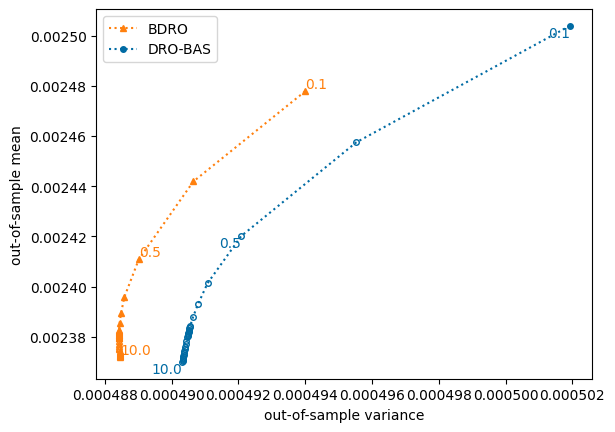

In [14]:
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")
fig, ax = plt.subplots()
df = agg_df.loc[(posterior_sr == 1) | (posterior_sr == 30)]
df = df.loc[:,:,0.1:]
df.loc[:, "is_maximise_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
gb = df.groupby("algorithm")
for algorithm, group_df in gb:
    mean_variance_plot(ax, group_df, is_labelled=True, offset=0, alpha=1.0, **algorithm_style(algorithm), pareto_front_col="is_maximise_pareto_front")
ax.legend()
ax.set_xlabel("out-of-sample variance")
ax.set_ylabel("out-of-sample mean")
fig.show()

In [6]:
num_time_windows = math.floor((len(returns_df) - IN_SAMPLE_TIME_WINDOW) / OUT_OF_SAMPLE_TIME_WINDOW)
num_stocks = int(len(returns_df.columns))

In [20]:
week_cols = [f"week_{i}" for i in range(OUT_OF_SAMPLE_TIME_WINDOW)]
stock_cols = [f"stock_{i}" for i in range(num_stocks)]
dro_returns = {week: [] for week in week_cols}
for stock in stock_cols:
    dro_returns[stock] = []
dro_returns["uuid"] = []
dro_returns["replication"] = []
for idx, row in results_df[["out_of_sample_costs", "solution"]].iterrows():
    uuid, replication = idx
    str_cost, str_solution = row["out_of_sample_costs"], row["solution"]
    if str_cost == "[]":
        costs = [np.nan for _ in range(OUT_OF_SAMPLE_TIME_WINDOW)]
    else:
        costs = [float(x) for x in str_cost.strip('[]').split(',')]
    solution = [float(x) for x in str_solution.strip('[]').split(',')]
    dro_returns["uuid"].append(uuid)
    dro_returns["replication"].append(replication)
    for i, week in enumerate(week_cols):
        dro_returns[week].append(costs[i])
    for i, stock in enumerate(stock_cols):
        dro_returns[stock].append(solution[i])

dro_returns_df = pd.DataFrame(dro_returns).set_index(["uuid", "replication"])
dro_returns_df

week_0    week_1  \
uuid                                 replication                       
7e5dffc9-6dc9-4911-8a78-4efd35eb355f 0            0.003494 -0.007274   
                                     1           -0.011795  0.055356   
                                     2            0.014962 -0.010116   
                                     3            0.018145  0.049906   
                                     4            0.019858  0.000575   
...                                                    ...       ...   
f0992b8e-fa07-4f37-ac03-972234b6d8e1 104          0.009868 -0.024297   
                                     105          0.003496  0.002502   
                                     106          0.017377  0.005929   
                                     107          0.050680  0.022293   
                                     108          0.015893 -0.020701   

                                                    week_2    week_3  \
uuid                                 replication                       
7e5dffc9-6dc9-4911-8a78-4efd35eb355f 0           -0.006280  0.029726   
                                     1            0.001180 -0.028777   
                                     2            0.058993  0.013328   
                                     3           -0.009691 -0.032008   
                                     4            0.040274 -0.017328   
...                                                    ...       ...   
f0992b8e-fa07-4f37-ac03-972234b6d8e1 104          0.019263  0.020621   
                                     105          0.003934 -0.000744   
                                     106         -0.033696  0.010995   
                                     107          0.003603  0.027736   
                                     108         -0.040267 -0.021895   

                                                    week_4    week_5  \
uuid                                 replication                       
7e5dffc9-6dc9-4911-8a78-4efd35eb355f 0            0.013768  0.008630   
                                     1            0.037771 -0.047999   
                                     2           -0.043531  0.013507   
                                     3            0.035008  0.012059   
                                     4           -0.035044  0.032011   
...                                                    ...       ...   
f0992b8e-fa07-4f37-ac03-972234b6d8e1 104          0.003210  0.010580   
                                     105          0.009701 -0.005232   
                                     106          0.002695 -0.001943   
                                     107          0.012123 -0.008600   
                                     108         -0.004321  0.032389   

                                                    week_6    week_7  \
uuid                                 replication                       
7e5dffc9-6dc9-4911-8a78-4efd35eb355f 0            0.052761  0.022545   
                                     1            0.033606  0.000908   
                                     2            0.025507 -0.004823   
                                     3            0.040930  0.015194   
                                     4           -0.031360  0.015623   
...                                                    ...       ...   
f0992b8e-fa07-4f37-ac03-972234b6d8e1 104         -0.017301 -0.003395   
                                     105         -0.008831 -0.019390   
                                     106         -0.094447  0.039085   
                                     107         -0.012242  0.017587   
                                     108         -0.021343  0.001006   

                                                    week_8    week_9  ...  \
uuid                                 replication                      ...   
7e5dffc9-6dc9-4911-8a78-4efd35eb355f 0           -0.004190 -0.032804  ...   
                                     1            0.061508  0.006298  ...

In [8]:
# join the dataframes, the sort and groupby
results_df = results_df.join(dro_returns_df)

In [9]:
results_df = results_df.loc[(results_df["num_posterior_samples"] == 30) | (results_df["num_posterior_samples"] == 1)]
gb = results_df.groupby(["algorithm", "epsilon", "num_posterior_samples"])

In [10]:
for (algorithm, epsilon, num_posterior_samples), group_df in gb:
    dro_bas_returns = group_df[week_cols].values.flatten()
    print(algorithm, epsilon, np.sum(dro_bas_returns))

kl_bdro 0.01 3.7945357662412444
kl_bdro 0.02 3.4958483471627333
kl_bdro 0.05 3.313254983003008
kl_bdro 0.1 3.2409479005308466
kl_bdro 0.2 3.1940160657882335
kl_bdro 0.5 3.1534685685691985
kl_bdro 1.0 3.1338384071903587
kl_bdro 1.5 3.1252770715586706
kl_bdro 2.0 3.120217217374804
kl_bdro 2.5 3.1167702828745854
kl_bdro 2.6 3.1161945294017337
kl_bdro 2.7 3.115662511948667
kl_bdro 2.8 3.115164522365092
kl_bdro 2.9 3.1146911985001715
kl_bdro 3.0 3.114237666258142
kl_bdro 3.1 3.1138063595402214
kl_bdro 3.2 3.113396931620618
kl_bdro 3.3 3.113019666227149
kl_bdro 3.4 3.112666931905956
kl_bdro 3.5 3.1123137896230118
kl_bdro 4.0 3.1107461219125536
kl_bdro 4.5 3.1094583486455467
kl_bdro 5.0 3.108365026467071
kl_bdro 5.5 3.1074243319546317
kl_bdro 6.0 3.1066139516600586
kl_bdro 6.5 3.1058918177935197
kl_bdro 7.0 3.105258068508498
kl_bdro 7.5 3.1046746638647633
kl_bdro 8.0 3.1041595530198056
kl_bdro 8.5 3.1036885264407323
kl_bdro 9.0 3.1032617878483317
kl_bdro 9.5 3.1028652957560374
kl_bdro 10.0 3.

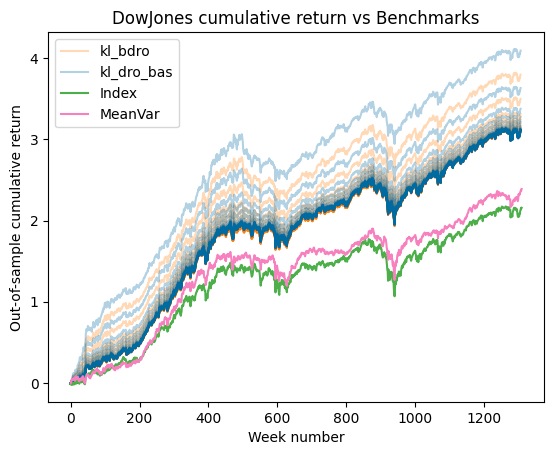

In [11]:
# dro_bas_returns = solution_returns.flatten()
bdro_labelled = False
dro_bas_labelled = False
for (algorithm, epsilon, num_posterior_samples), group_df in gb:
    dro_returns = group_df[week_cols].values.flatten()
    if not dro_bas_labelled and algorithm == "kl_dro_bas":
        label = algorithm
        dro_bas_labelled = True
    elif not bdro_labelled and algorithm == "kl_bdro":
        label = algorithm
        bdro_labelled = True
    else:
        label='_nolegend_'
    plt.plot(np.cumsum(dro_returns), label=label, alpha=0.3, color=AlgorithmColor[algorithm].value)
CB_color_cycle = ['#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
plt.plot(np.cumsum(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:].values), label="Index", color=CB_color_cycle[0])
# for baseline_model in ["CZeSD", "KP_SSD", "L_SSD", "LR_ASSD", "MeanVar", "RMZ_SSD"]:

for i, baseline_model in enumerate(["MeanVar"]):
    baseline_portfolio_txt = mmc2_dir / "Solutions" / dgp / f"OptPortfolios_{baseline_model}_{dgp}.txt"
    baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
    baseline_returns_txt = mmc2_dir / "Solutions" / dgp / f"OutofSamplePortReturns_{baseline_model}_{dgp}_List.txt" 
    baseline_returns = np.loadtxt(baseline_returns_txt)
    plt.plot(np.cumsum(baseline_returns), label=baseline_model, color=CB_color_cycle[i+1])

plt.xlabel("Week number")
plt.ylabel("Out-of-sample cumulative return")
plt.title(dgp + r" cumulative return vs Benchmarks")
plt.legend()
plt.show()

In [22]:

for epsilon, group_df in results_df.groupby("epsilon"):
    print(group_df[stock_cols].values)

KeyError: "None of [Index(['stock_0', 'stock_1', 'stock_2', 'stock_3', 'stock_4', 'stock_5',\n       'stock_6', 'stock_7', 'stock_8', 'stock_9', 'stock_10', 'stock_11',\n       'stock_12', 'stock_13', 'stock_14', 'stock_15', 'stock_16', 'stock_17',\n       'stock_18', 'stock_19', 'stock_20', 'stock_21', 'stock_22', 'stock_23',\n       'stock_24', 'stock_25', 'stock_26', 'stock_27'],\n      dtype='object')] are in the [columns]"